# 0. Libraries

In [1]:
! pip install simplemma

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.5/75.5 MB 12.6 MB/s eta 0:00:0000:0100:01


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
import warnings

# Filter out the specific UserWarnings
warnings.filterwarnings("ignore", category=UserWarning, message="A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy")
warnings.filterwarnings("ignore", category=UserWarning, message="unable to load libtensorflow_io_plugins.so")
warnings.filterwarnings("ignore", category=UserWarning, message="file system plugins are not loaded")

In [4]:
# Hugging Face library
from transformers import AutoTokenizer, TFAutoModel

In [5]:
# Hugging Face library
from datasets import Dataset, DatasetDict

In [6]:
import re
import nltk
import simplemma
import spacy

from simplemma import text_lemmatizer
from nltk.corpus import stopwords

# 1. Load Datasets

In [7]:
# Create a function to import the data from csv format
def load_data(file_path):
    return pd.read_csv(file_path, header=None, delimiter='\t', names=['emotion', 'text'])


train_path = '/kaggle/input/emotion/train-emotion-all.tsv'
test_path = '/kaggle/input/emotion/test-emotion-all.tsv'
val_path = '/kaggle/input/emotion/valid-emotion-all.tsv'

df_train = load_data(train_path)
df_test = load_data(test_path)
df_val = load_data(val_path)

In [8]:
# To get an idea of the data
pd.set_option('display.max_colwidth', 150)
df_train.head()

,emotion,text
0,NEUTRA,Il ministro della Salute
1,GIOIA,". “Ho parlato di #bodyshaming e #fatshaming in Parlamento, perché credo che solo nominarli faccia bene e perchè molta pubblicistica ha relegato qu..."
2,NEUTRA,Se gli editori dell ' Aie sono in polemica per l ' intervento sugli sconti
3,RABBIA,"1 Maggio 2020 #Milano, duplice violenza sessuale: preso maniaco seriale nigeriano Clandestinamente in Italia dal 2018 aveva segnalazioni per atti ..."
4,AMORE,amore mio per sempre


In [9]:
# Remove user mention here. could not do it in the preprocess function
df_train['text'] = df_train['text'].str.replace('@[A-Za-z0-9]+\s?', '', regex=True)
df_val['text'] = df_val['text'].str.replace('@[A-Za-z0-9]+\s?', '', regex=True)
df_test['text'] = df_test['text'].str.replace('@[A-Za-z0-9]+\s?', '', regex=True)

In [10]:
# I'm combining the pandas dataframe to the dataset dictionary of Hugging Face

train_dataset = Dataset.from_pandas(df_train)
test_dataset = Dataset.from_pandas(df_test)
val_dataset = Dataset.from_pandas(df_val)

# Create the DatasetDict
dataset = DatasetDict({'train': train_dataset, 'test': test_dataset, 'validation': val_dataset})

print(dataset)

DatasetDict({
    train: Dataset({
        features: ['emotion', 'text'],
        num_rows: 1854
    })
    test: Dataset({
        features: ['emotion', 'text'],
        num_rows: 546
    })
    validation: Dataset({
        features: ['emotion', 'text'],
        num_rows: 327
    })
})


## 1.5 Check Duplicates

In [11]:
# Initialize a dictionary to store updated datasets
updated_datasets = {}

# Check for and remove duplicates in each split
for split in dataset.keys():
    split_data = dataset[split]
    
    # Access the 'text' column within the list
    text_column = split_data['text']
    
    # Initialize a set to track unique texts
    unique_texts = set()
    
    # Initialize lists to store the filtered data
    filtered_text = []
    
    # Iterate through the 'text' column and filter duplicates
    for text in text_column:
        if text not in unique_texts:
            unique_texts.add(text)
            filtered_text.append(text)
    
    # Create a new Dataset object with the filtered data
    updated_datasets[split] = split_data.select(list(range(len(filtered_text))))
    
    # Print the number of removed duplicates
    duplicate_count = len(text_column) - len(filtered_text)
    print(f"Duplicates removed in {split} split: {duplicate_count}\n")

# Update the dataset dictionary with the filtered datasets
dataset.update(updated_datasets)

# Print the updated dataset information
for split in dataset.keys():
    split_data = dataset[split]
    print(f"{split}: {len(split_data['text'])} rows")

print(dataset)

Duplicates removed in train split: 73

Duplicates removed in test split: 3

Duplicates removed in validation split: 9

train: 1781 rows
test: 543 rows
validation: 318 rows
DatasetDict({
    train: Dataset({
        features: ['emotion', 'text'],
        num_rows: 1781
    })
    test: Dataset({
        features: ['emotion', 'text'],
        num_rows: 543
    })
    validation: Dataset({
        features: ['emotion', 'text'],
        num_rows: 318
    })
})


In [12]:
dataset['train']['text'][0:2]

[' Il ministro della Salute ',
 '. “Ho parlato di #bodyshaming e #fatshaming in Parlamento, perché credo che solo nominarli faccia bene e perchè molta pubblicistica ha relegato questi temi come qualcosa che riguarda le donne; poteva avere un significato che ne parlasse una voce maschile”']

# 2. Emotion Distribution

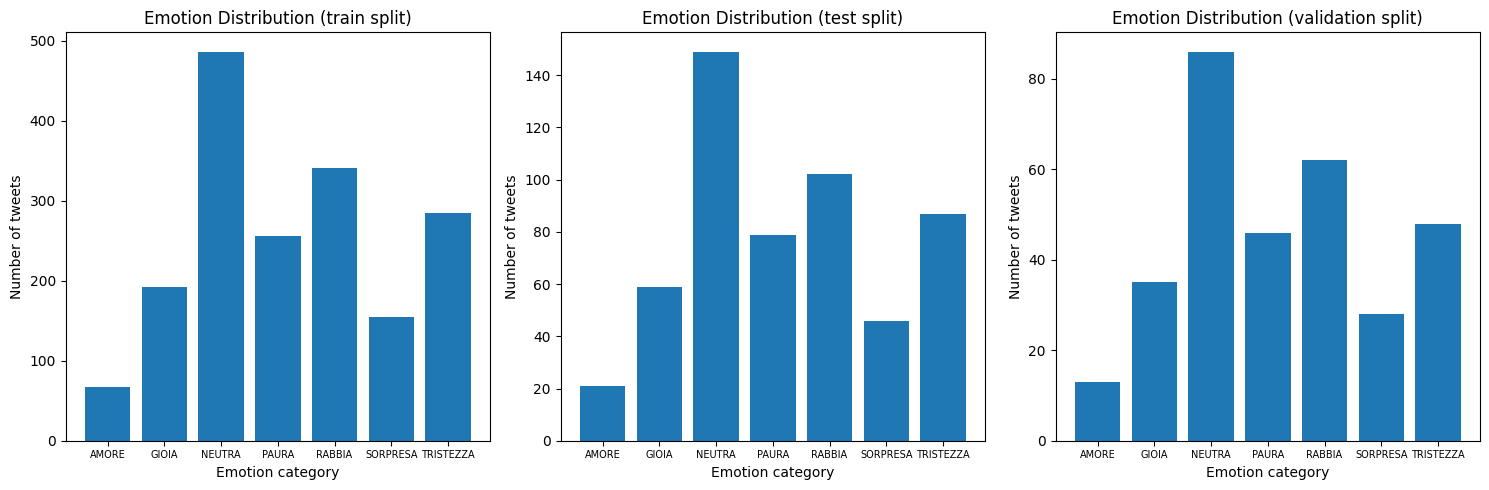

In [13]:
from collections import Counter

# Initialize dictionaries to store sentiment counts and categories for each split
emotion_counts = {}
emotion_categories = {}

# Loop through each split
for split in dataset.keys():
    split_data = dataset[split]
    
    # Extract emotion data from the 'emotion' column within the list
    emotion_data = [item for item in split_data['emotion']]
    
    # Calculate sentiment counts for the current split using Counter
    emotion_count = Counter(emotion_data)
    emotion_counts[split] = emotion_count
    
    # Get unique emotion categories for the current split
    emotion_category = list(emotion_count.keys())
    emotion_categories[split] = emotion_category

# Combine all unique sentiment categories across all splits and sort them
all_emotion_categories = sorted(set().union(*emotion_categories.values()))

# Create subplots for each split
fig, axs = plt.subplots(1, 3, figsize=(15, 5))

#max_y_value = 0
# Loop through each split and plot the sentiment counts
for i, split in enumerate(dataset.keys()):
    x = np.array(all_emotion_categories)
    y = np.array([emotion_counts[split].get(category, 0) for category in x])
    axs[i].bar(x, y)
    
    
    
    axs[i].set_title(f"Emotion Distribution ({split} split)")
    axs[i].set_xlabel("Emotion category")
    axs[i].set_ylabel("Number of tweets")
    
    axs[i].tick_params(axis='x', labelsize=7)
    #max_y_value = max(max_y_value, max(y))
    
# Set a common y-axis range for all subplots
#for i in range(3):
    #axs[i].set_ylim(0, max_y_value)

plt.tight_layout()

plt.savefig('emotion_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

# 3. WordCloud

In [14]:
!python -m spacy download it_core_news_md

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.4/42.4 MB 15.0 MB/s eta 0:00:0000:0100:01
✔ Download and installation successful
You can now load the package via spacy.load('it_core_news_md')


In [15]:
import spacy

# Load the Italian language model
nlp = spacy.load("it_core_news_md")

In [16]:
italian_stopwords = set(stopwords.words('italian'))

# Define a function to preprocess text
def preprocess_text(text):    
    # Tokenization, lemmatization, removing punctuation, stopwords and URLs
    doc = nlp(text)
    nouns = [token.text for token in doc if token.pos_ == 'NOUN']
    
    
    text = ' '.join(nouns)
    
    text = text_lemmatizer(text, lang='it')
    text = ' '.join(text)
    
    text = re.sub(r'[^\w\s\']', '', text)
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    
    text = ' '.join(word for word in text.split() if word.lower() not in italian_stopwords)
    

    
    return text




def preprocess_dataset(dataset):
    dataset['text'] = preprocess_text(dataset['text'])
    return dataset

dataset = dataset.map(preprocess_dataset)

  0%|          | 0/1781 [00:00<?, ?ex/s]

  0%|          | 0/543 [00:00<?, ?ex/s]

  0%|          | 0/318 [00:00<?, ?ex/s]

In [17]:
from wordcloud import WordCloud

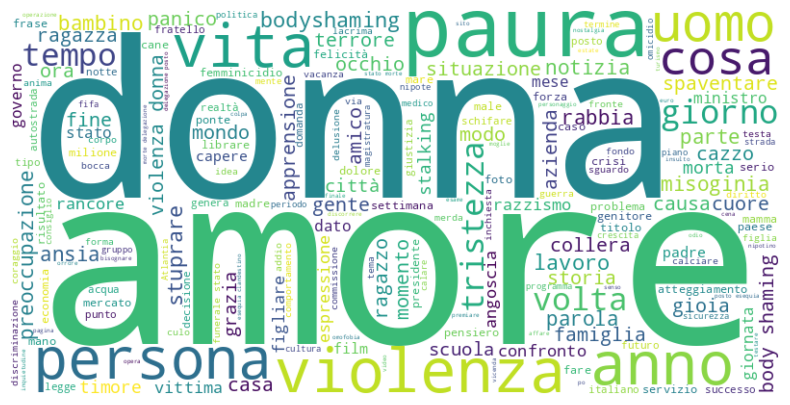

In [18]:
# Create a WordCloud object

# Combine the text from 'train', 'test', and 'validation' splits
combined_text = []

for split in ['train', 'test', 'validation']:
    combined_text.extend([text for text in dataset[split]['text']])

# Concatenate the combined text into a single string
text = ' '.join(combined_text)

wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)

# Display the word cloud using matplotlib
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")  # Turn off axis labels
plt.savefig('emotion_wordcloud.png', dpi=300, bbox_inches='tight')
plt.show()

# 4. Checking word distribution among classes

In [19]:
# Create empty lists for each class
tristezza_words = []
gioia_words = []
amore_words = []
rabbia_words = []
paura_words = []
sorpresa_words = []
neutra_words = []

for split in dataset.keys():
    for text, emotion in zip(dataset[split]['text'], dataset[split]['emotion']):
        # Split the text into words
        words = text.split()
        
        # Check the emotion label and append the words to the corresponding list
        if emotion == 'TRISTEZZA':
            tristezza_words.extend(words)
        elif emotion == 'GIOIA':
            gioia_words.extend(words)
        elif emotion == 'AMORE':
            amore_words.extend(words)
        elif emotion == 'RABBIA':
            rabbia_words.extend(words)
        elif emotion == 'PAURA':
            paura_words.extend(words)
        elif emotion == 'SORPRESA':
            sorpresa_words.extend(words)
        elif emotion == 'NEUTRA':
            neutra_words.extend(words)



In [20]:
from nltk.probability import FreqDist


fdist_tristezza = FreqDist(tristezza_words)
fdist_gioia = FreqDist(gioia_words)
fdist_amore = FreqDist(amore_words)
fdist_rabbia = FreqDist(rabbia_words)
fdist_paura = FreqDist(paura_words)
fdist_sorpresa = FreqDist(sorpresa_words)
fdist_neutra = FreqDist(neutra_words)

In [26]:
# Get the most common words for each emotion category
top_words_tristezza = fdist_tristezza.most_common(10000)
top_words_gioia = fdist_gioia.most_common(10000)
top_words_amore = fdist_amore.most_common(10000)
top_words_rabbia = fdist_rabbia.most_common(10000)
top_words_paura = fdist_paura.most_common(10000)
top_words_sorpresa = fdist_sorpresa.most_common(10000)
top_words_neutra = fdist_neutra.most_common(10000)

# Unzip the top words and frequencies for each emotion
top_words_tristezza, frequencies_tristezza = zip(*top_words_tristezza)
top_words_gioia, frequencies_gioia = zip(*top_words_gioia)
top_words_amore, frequencies_amore = zip(*top_words_amore)
top_words_rabbia, frequencies_rabbia = zip(*top_words_rabbia)
top_words_paura, frequencies_paura = zip(*top_words_paura)
top_words_sorpresa, frequencies_sorpresa = zip(*top_words_sorpresa)
top_words_neutra, frequencies_neutra = zip(*top_words_neutra)

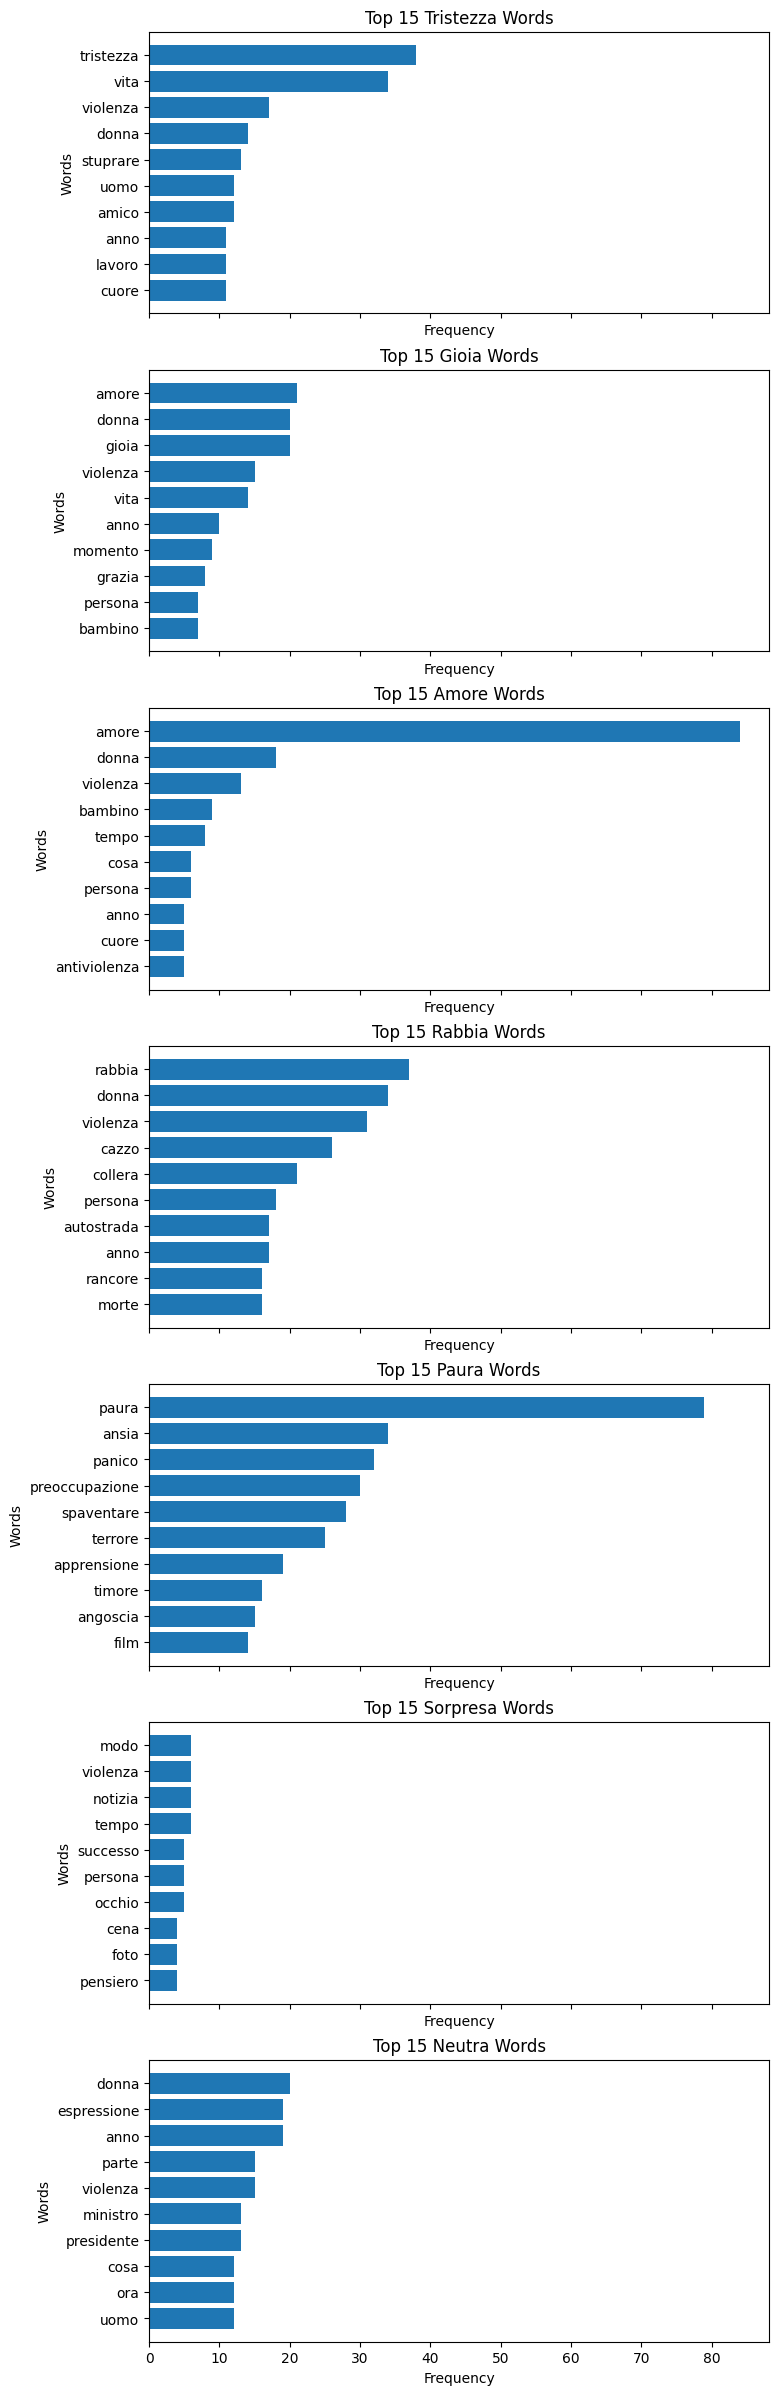

In [22]:
# Create subplots
fig, axes = plt.subplots(7, 1, figsize=(8, 30), sharex=True)

# Plot for Tristezza words
axes[0].barh(top_words_tristezza, frequencies_tristezza)
axes[0].set_xlabel('Frequency')
axes[0].set_ylabel('Words')
axes[0].set_title('Top 10 Tristezza Words')
axes[0].invert_yaxis()

# Plot for Gioia words
axes[1].barh(top_words_gioia, frequencies_gioia)
axes[1].set_xlabel('Frequency')
axes[1].set_ylabel('Words')
axes[1].set_title('Top 10 Gioia Words')
axes[1].invert_yaxis()

# Plot for Amore words
axes[2].barh(top_words_amore, frequencies_amore)
axes[2].set_xlabel('Frequency')
axes[2].set_ylabel('Words')
axes[2].set_title('Top 10 Amore Words')
axes[2].invert_yaxis()

# Plot for Rabbia words
axes[3].barh(top_words_rabbia, frequencies_rabbia)
axes[3].set_xlabel('Frequency')
axes[3].set_ylabel('Words')
axes[3].set_title('Top 10 Rabbia Words')
axes[3].invert_yaxis()

# Plot for Paura words
axes[4].barh(top_words_paura, frequencies_paura)
axes[4].set_xlabel('Frequency')
axes[4].set_ylabel('Words')
axes[4].set_title('Top 10 Paura Words')
axes[4].invert_yaxis()

# Plot for Sorpresa words
axes[5].barh(top_words_sorpresa, frequencies_sorpresa)
axes[5].set_xlabel('Frequency')
axes[5].set_ylabel('Words')
axes[5].set_title('Top 10 Sorpresa Words')
axes[5].invert_yaxis()

# Plot for Neutra words
axes[6].barh(top_words_neutra, frequencies_neutra)
axes[6].set_xlabel('Frequency')
axes[6].set_ylabel('Words')
axes[6].set_title('Top 10 Neutra Words')
axes[6].invert_yaxis()


plt.show()


# 5. Words Impact

## 5.1 TF

In [27]:
# Calculate the total number of words in each emotion category
total_words_in_tristezza = sum(frequencies_tristezza)
total_words_in_gioia = sum(frequencies_gioia)
total_words_in_amore = sum(frequencies_amore)
total_words_in_rabbia = sum(frequencies_rabbia)
total_words_in_paura = sum(frequencies_paura)
total_words_in_sorpresa = sum(frequencies_sorpresa)
total_words_in_neutra = sum(frequencies_neutra)

# Create a dictionary to store the word impact index for each category
word_impact_index = {}

# Calculate the relative frequency of each word within its category for TRISTEZZA
for word, frequency in zip(top_words_tristezza, frequencies_tristezza):
    relative_frequency = frequency / total_words_in_tristezza
    word_impact_index.setdefault(word, {'TRISTEZZA': 0, 'GIOIA': 0, 'AMORE': 0, 'RABBIA': 0, 'PAURA': 0, 'SORPRESA': 0, 'NEUTRA': 0})
    word_impact_index[word]['TRISTEZZA'] = relative_frequency

# Calculate the relative frequency of each word within its category for GIOIA
for word, frequency in zip(top_words_gioia, frequencies_gioia):
    relative_frequency = frequency / total_words_in_gioia
    word_impact_index.setdefault(word, {'TRISTEZZA': 0, 'GIOIA': 0, 'AMORE': 0, 'RABBIA': 0, 'PAURA': 0, 'SORPRESA': 0, 'NEUTRA': 0})
    word_impact_index[word]['GIOIA'] = relative_frequency

# Calculate the relative frequency of each word within its category for AMORE
for word, frequency in zip(top_words_amore, frequencies_amore):
    relative_frequency = frequency / total_words_in_amore
    word_impact_index.setdefault(word, {'TRISTEZZA': 0, 'GIOIA': 0, 'AMORE': 0, 'RABBIA': 0, 'PAURA': 0, 'SORPRESA': 0, 'NEUTRA': 0})
    word_impact_index[word]['AMORE'] = relative_frequency
    
# Calculate the relative frequency of each word within its category for RABBIA
for word, frequency in zip(top_words_rabbia, frequencies_rabbia):
    relative_frequency = frequency / total_words_in_rabbia
    word_impact_index.setdefault(word, {'TRISTEZZA': 0, 'GIOIA': 0, 'AMORE': 0, 'RABBIA': 0, 'PAURA': 0, 'SORPRESA': 0, 'NEUTRA': 0})
    word_impact_index[word]['RABBIA'] = relative_frequency
    
# Calculate the relative frequency of each word within its category for PAURA
for word, frequency in zip(top_words_paura, frequencies_paura):
    relative_frequency = frequency / total_words_in_paura
    word_impact_index.setdefault(word, {'TRISTEZZA': 0, 'GIOIA': 0, 'AMORE': 0, 'RABBIA': 0, 'PAURA': 0, 'SORPRESA': 0, 'NEUTRA': 0})
    word_impact_index[word]['PAURA'] = relative_frequency
    
# Calculate the relative frequency of each word within its category for SORPRESA
for word, frequency in zip(top_words_sorpresa, frequencies_sorpresa):
    relative_frequency = frequency / total_words_in_sorpresa
    word_impact_index.setdefault(word, {'TRISTEZZA': 0, 'GIOIA': 0, 'AMORE': 0, 'RABBIA': 0, 'PAURA': 0, 'SORPRESA': 0, 'NEUTRA': 0})
    word_impact_index[word]['SORPRESA'] = relative_frequency

# Calculate the relative frequency of each word within its category for NEUTRA
for word, frequency in zip(top_words_neutra, frequencies_neutra):
    relative_frequency = frequency / total_words_in_neutra
    word_impact_index.setdefault(word, {'TRISTEZZA': 0, 'GIOIA': 0, 'AMORE': 0, 'RABBIA': 0, 'PAURA': 0, 'SORPRESA': 0, 'NEUTRA': 0})
    word_impact_index[word]['NEUTRA'] = relative_frequency
    

# Define the number of decimal places to round to
decimal_places = 3  # You can adjust this to your desired number of decimal places

# Round the word impact values in the word_impact_index dictionary
for word, impact_values in word_impact_index.items():
    for emotion, value in impact_values.items():
        # Check if the value is a float (to avoid rounding integers)
        if isinstance(value, float):
            word_impact_index[word][emotion] = round(value, decimal_places)


In [41]:
word_impact_index['amore']

{'TRISTEZZA': 0.002,
 'GIOIA': 0.025,
 'AMORE': 0.154,
 'RABBIA': 0.001,
 'PAURA': 0,
 'SORPRESA': 0,
 'NEUTRA': 0}

## 5.2 IDF